# Water Potability — Data Preprocessing Pipeline

**Group:** J

**Member 1:** LEE JOE ANN (1211112337)

**Member 2:** QUAH MING YI (1211112365)

**Dataset:** `water_potability.csv`  

**Target variable:** `Potability` (0 = Not potable, 1 = Potable)  

**Features:** 9 numeric water quality measurements


---

In [1]:
!pip install pandas matplotlib numpy scikit-learn seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_path = 'water_potability.csv'
df_raw = pd.read_csv(data_path)
df = df_raw.copy()

df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
# statistical summary

display(df.info())
print(f'\nShape: {df.shape}\n')
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


None


Shape: (3276, 10)



,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


Target Variable Distribution: 
Potability
0    1998
1    1278
Name: count, dtype: int64
0 = Not Potable (unsafe)
1 = Potable (safe to drink)


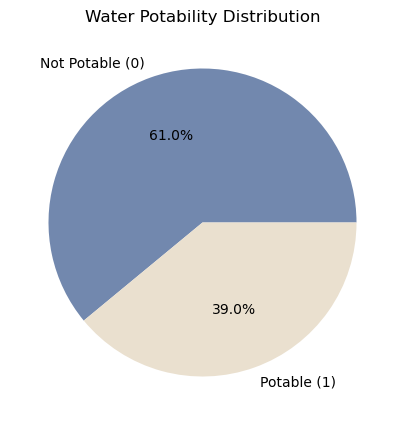

In [4]:
import seaborn as sns
print('Target Variable Distribution: ')
print(df['Potability'].value_counts())
print('0 = Not Potable (unsafe)')
print('1 = Potable (safe to drink)')

#Pie chart for visualization
df['Potability'].value_counts().plot(
    kind='pie',
    labels=['Not Potable (0)', 'Potable (1)'],
    autopct='%1.1f%%',
    colors=['#7288AE', '#EAE0CF'],
    figsize=(5, 5)
)
plt.title('Water Potability Distribution')
plt.ylabel('')
plt.show()

# 1.Data Cleaning

In [5]:
# 1.1 Check for missing value
missing = df.isnull().sum()
missing_percentage = (missing/len(df)*100).round(2)
missing_df = pd.DataFrame({'Missing Count':missing, 'Missing %': missing_percentage})
missing_df = missing_df[missing_df['Missing Count']>0].sort_values('Missing %', ascending=False)
display(missing)
display(missing_df)

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

,Missing Count,Missing %
Sulfate,781,23.84
ph,491,14.99
Trihalomethanes,162,4.95


In [6]:
#imputation
df['ph'] = df['ph'].fillna(df['ph'].mean())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].median())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].median())

#check for missing value again
print(df.isnull().sum())

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [7]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.073546,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
#1.2 check for duplicated rows
duplicated = df.duplicated().sum()
print(f'Duplicate rows found: {duplicated}')

if duplicated > 0:
    df = df.drop_duplicates()
    df.reset_index(drop=True, inplace=True)
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates - dataset is clean.')

Duplicate rows found: 0
No duplicates - dataset is clean.


In [9]:
#1.3 Check for Inconsistencies
print('Min and Max values for each features')
df.describe().loc[['min','max']].round(2)

Min and Max values for each features


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
min,0.0,47.43,320.94,0.35,129.00,181.48,2.2,0.74,1.45,0.0
max,14.0,323.12,61227.20,13.13,481.03,753.34,28.3,124.00,6.74,1.0


In [10]:
invalid_ph = df[(df['ph']<0)|(df['ph']>14)]
print(f'pH values outside 0-14 range: {len(invalid_ph)}')

features = ['Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon','Trihalomethanes', 'Turbidity']

print("\nNegative values check (should be 0)")
for col in features:
    n_neg = (df[col]<0).sum()
    print(f'{col:20s}:{n_neg} negative values')

pH values outside 0-14 range: 0

Negative values check (should be 0)
Hardness            :0 negative values
Solids              :0 negative values
Chloramines         :0 negative values
Sulfate             :0 negative values
Conductivity        :0 negative values
Organic_carbon      :0 negative values
Trihalomethanes     :0 negative values
Turbidity           :0 negative values


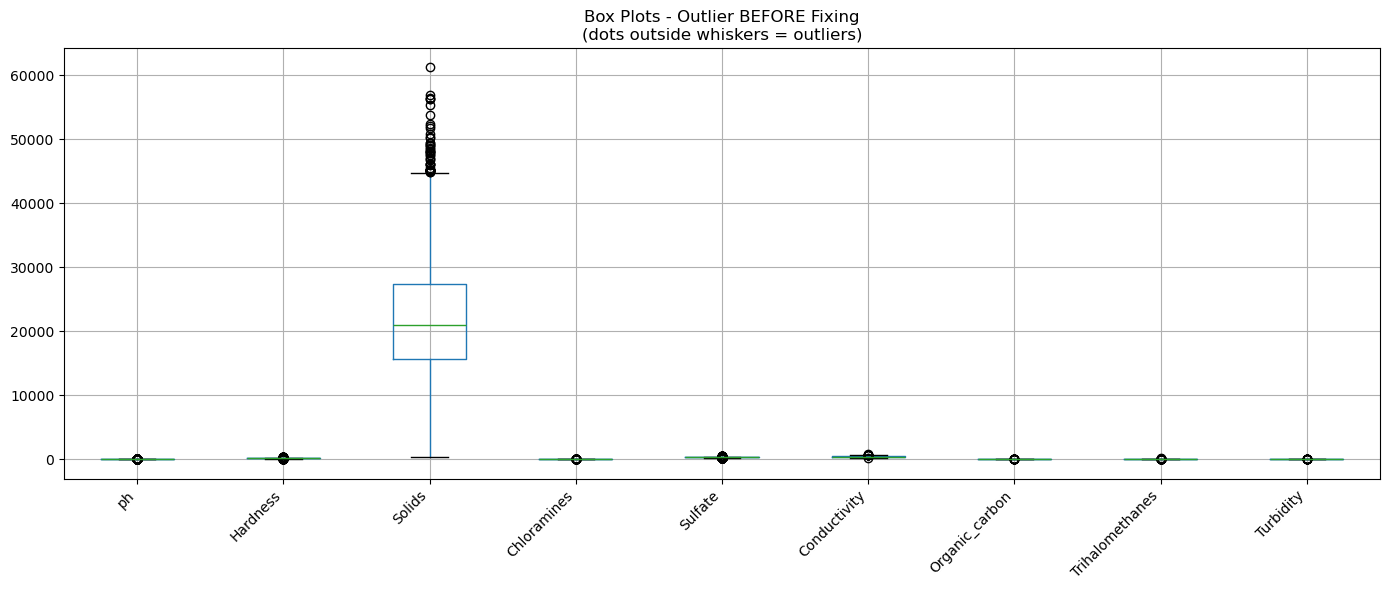

In [11]:
#1.4 Check for outliers using box plot and IQR
features = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
            'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

plt.figure(figsize=(14,6))
df[features].boxplot()
plt.xticks(rotation=45, ha='right')
plt.title('Box Plots - Outlier BEFORE Fixing\n(dots outside whiskers = outliers)')
plt.tight_layout()
plt.show()

In [12]:
print('Outlier count per feature (IQR Method):')

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5 * IQR     # lower boundary
    upper_fence = Q3 + 1.5 * IQR     # upper boundary
    
    # Count values outside the boundaries
    n_outliers = ((df[col] < lower_fence) | (df[col] > upper_fence)).sum()
    pct = round(n_outliers / len(df) * 100, 2)
    
    print(f'  {col:20s}: {n_outliers:>4} outliers ({pct}%)')

Outlier count per feature (IQR Method):
  ph                  :  142 outliers (4.33%)
  Hardness            :   83 outliers (2.53%)
  Solids              :   47 outliers (1.43%)
  Chloramines         :   61 outliers (1.86%)
  Sulfate             :  264 outliers (8.06%)
  Conductivity        :   11 outliers (0.34%)
  Organic_carbon      :   25 outliers (0.76%)
  Trihalomethanes     :   54 outliers (1.65%)
  Turbidity           :   19 outliers (0.58%)


In [13]:
#Fix outliers by CAPPING (Winsorisation)
print("Capping outliers for all features: ")
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5 * IQR     # lower boundary
    upper_fence = Q3 + 1.5 * IQR     # upper boundary
    
    df[col] = df[col].clip(lower=lower_fence, upper=upper_fence)
    print(f' {col:20s}: Capped to [{lower_fence:.2f}, {upper_fence:.2f}]')

print("\nOutliers capped for all features!")

Capping outliers for all features: 
 ph                  : Capped to [3.89, 10.26]
 Hardness            : Capped to [117.13, 276.39]
 Solids              : Capped to [-1832.42, 44831.87]
 Chloramines         : Capped to [3.15, 11.10]
 Sulfate             : Capped to [267.16, 400.32]
 Conductivity        : Capped to [191.65, 655.88]
 Organic_carbon      : Capped to [5.33, 23.30]
 Trihalomethanes     : Capped to [26.62, 106.70]
 Turbidity           : Capped to [1.85, 6.09]

Outliers capped for all features!


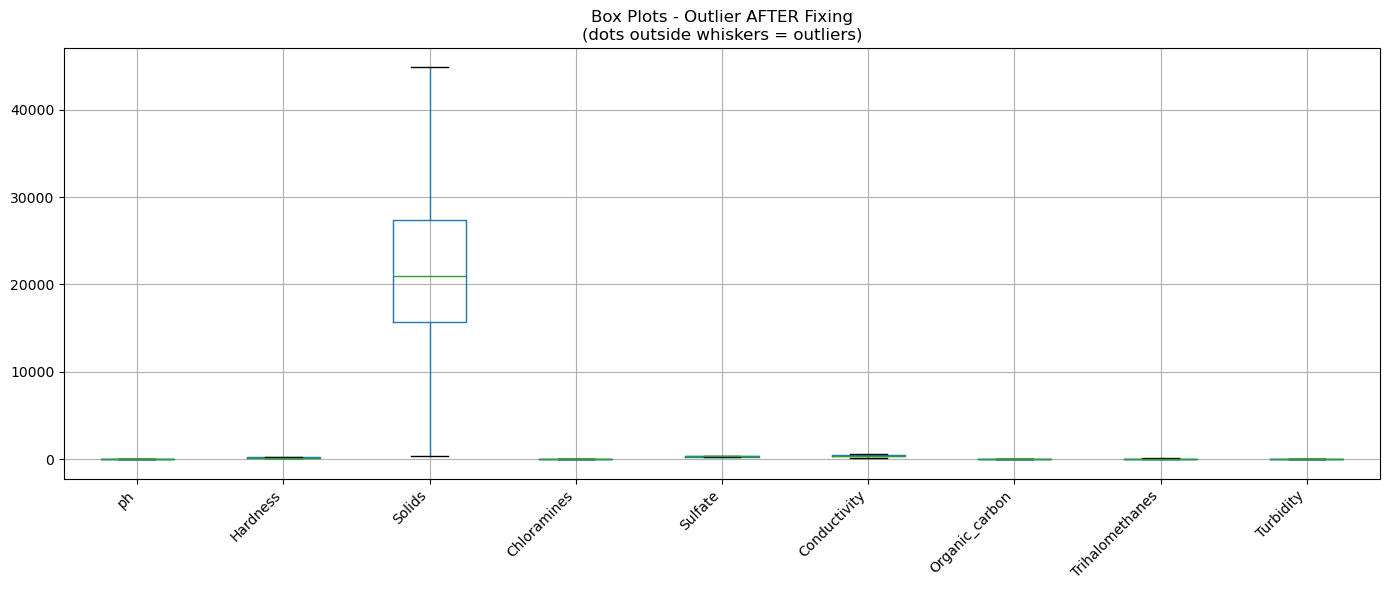


 Dataset shape after cleaning: (3276, 10)


In [14]:
plt.figure(figsize=(14,6))
df[features].boxplot()
plt.xticks(rotation=45, ha='right')
plt.title('Box Plots - Outlier AFTER Fixing\n(dots outside whiskers = outliers)')
plt.tight_layout()
plt.show()

print(f'\n Dataset shape after cleaning: {df.shape}')

# 2. Data Transform

In [15]:
#2.1 Feature Engineering -- Add new features

df['ph_deviation'] = (df['ph'] - 7).abs()

#safe pH range (6.5 - 8.5)
df['is_safe_ph'] = ((df['ph'] >= 6.5) & (df['ph'] <= 8.5)).astype(int)

df['hardness_solids_ratio'] = df['Hardness'] / (df['Solids']+1)

print("New features created!")
print("Sample of new features: ")
df.sample(5)

New features created!
Sample of new features: 


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,ph_deviation,is_safe_ph,hardness_solids_ratio
1351,8.647454,183.597374,12995.885427,6.195449,382.357869,489.762799,18.076963,93.409614,3.624101,0,1.647454,0,0.014126
642,5.669690,194.130069,20081.537954,6.778104,333.073546,403.989920,18.284807,66.622485,3.592133,0,1.330310,0,0.009667
2839,7.243482,196.982379,29772.019247,6.497201,333.073546,322.365237,14.154955,50.655001,4.763579,1,0.243482,1,0.006616
2238,7.080795,197.713639,31251.643733,6.252423,333.073546,322.217629,14.271722,74.644268,3.906526,0,0.080795,1,0.006326
1203,8.719240,181.013100,17430.919720,7.421210,333.073546,289.202741,14.427225,55.393613,3.912836,1,1.719240,0,0.010384


In [16]:
print('pH Safety Flag Distribution: ')
print(df['is_safe_ph'].value_counts())
print()
print('1 = Safe pH range (WHO: 6.5-8.5)\n0 = Unsafe')

pH Safety Flag Distribution: 
is_safe_ph
1    1819
0    1457
Name: count, dtype: int64

1 = Safe pH range (WHO: 6.5-8.5)
0 = Unsafe


In [17]:
#2.2 Feature Scaling
from sklearn.model_selection import train_test_split as split
X = df.drop(columns=['Potability'])
y = df['Potability']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Feature columns: {X.columns.tolist()}')

X_train, X_test, y_train, y_test = split(X,y, test_size=0.2, random_state=42)

print(f'\nTraining size : {X_train.shape[0]}')
print(f'Test size: {X_test.shape[0]}')

print(f"\nTraining target: {y.shape[0]}")
print(y_train.value_counts())

X shape: (3276, 12)
y shape: (3276,)
Feature columns: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'ph_deviation', 'is_safe_ph', 'hardness_solids_ratio']

Training size : 2620
Test size: 656

Training target: 3276
Potability
0    1586
1    1034
Name: count, dtype: int64


In [18]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print('BEFORE Standard Scaling (Solids column)')
print(f"Mean: {X_train["Solids"].mean():.2f} Std:{X_train["Solids"].std():.2f}")
print("AFTER Standard Scaling (Solids column)")
print(f"Mean: {X_train_scaled["Solids"].mean():.4f} Std:{X_train_scaled["Solids"].std():.4f}")

#MinMaxScaler
mm_scaler = MinMaxScaler()
X_train_mm_scaled = mm_scaler.fit_transform(X_train)
X_test_mm_scaled = mm_scaler.transform(X_test)
X_train_mm_scaled = pd.DataFrame(X_train_mm_scaled, columns=X.columns)
X_test_mm_scaled  = pd.DataFrame(X_test_mm_scaled,  columns=X.columns)

print('\nBEFORE Min Max Scaling (Solids column)')
print(f"Mean: {X_train["Solids"].mean():.2f} Std:{X_train["Solids"].std():.2f}")
print("AFTER Min Max Scaling (Solids column)")
print(f"Mean: {X_train_mm_scaled["Solids"].mean():.4f} Std:{X_train_mm_scaled["Solids"].std():.4f}")

#RobustScaler
r_scaler = RobustScaler()
X_train_r_scaled = r_scaler.fit_transform(X_train)
X_test_r_scaled = r_scaler.transform(X_test)
X_train_r_scaled = pd.DataFrame(X_train_r_scaled, columns=X.columns)
X_test_r_scaled  = pd.DataFrame(X_test_r_scaled,  columns=X.columns)

print('\nBEFORE Robust Scaling (Solids column)')
print(f"Mean: {X_train["Solids"].mean():.2f} Std:{X_train["Solids"].std():.2f}")
print("AFTER Robust Scaling (Solids column)")
print(f"Mean: {X_train_r_scaled["Solids"].mean():.4f} Std:{X_train_r_scaled["Solids"].std():.4f}")


BEFORE Standard Scaling (Solids column)
Mean: 22003.86 Std:8642.94
AFTER Standard Scaling (Solids column)
Mean: 0.0000 Std:1.0002

BEFORE Min Max Scaling (Solids column)
Mean: 22003.86 Std:8642.94
AFTER Min Max Scaling (Solids column)
Mean: 0.4824 Std:0.1960

BEFORE Robust Scaling (Solids column)
Mean: 22003.86 Std:8642.94
AFTER Robust Scaling (Solids column)
Mean: 0.0944 Std:0.7537


# 3. Data Reduction

In [19]:
# 3.1 Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train_scaled, y_train)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'F-score': selector.scores_.round(4),
    'P-Value': selector.pvalues_.round(4)
})

# Sort by F-Score (highest = most important)
feature_scores = feature_scores.sort_values('F-score', ascending=False)
feature_scores = feature_scores.reset_index(drop=True)
feature_scores.index += 1   # start ranking from 1

print('Feature Importance Ranking (ANOVA F-Score):')
print('   Higher F-Score = more useful for predicting potability')
print()
print(feature_scores.to_string())

Feature Importance Ranking (ANOVA F-Score):
   Higher F-Score = more useful for predicting potability

                  Feature  F-score  P-Value
1            ph_deviation  14.6744   0.0001
2              is_safe_ph   9.6905   0.0019
3                  Solids   3.4956   0.0616
4          Organic_carbon   1.9266   0.1652
5                Hardness   0.6420   0.4230
6             Chloramines   0.5465   0.4598
7   hardness_solids_ratio   0.5220   0.4700
8         Trihalomethanes   0.4378   0.5083
9                 Sulfate   0.2815   0.5958
10                     ph   0.2417   0.6230
11              Turbidity   0.0450   0.8320
12           Conductivity   0.0129   0.9095


In [20]:
# Select top 7 features
K = 7
top_features = feature_scores['Feature'].head(K).tolist()

X_train_selected = X_train_scaled[top_features]
X_test_selected  = X_test_scaled[top_features]

print(f'Top {K} features selected:')
for i, feat in enumerate(top_features, 1):
    print(f'   {i}. {feat}')

print()
print(f'Shape before selection : {X_train_scaled.shape}')
print(f'Shape after selection  : {X_train_selected.shape}')

Top 7 features selected:
   1. ph_deviation
   2. is_safe_ph
   3. Solids
   4. Organic_carbon
   5. Hardness
   6. Chloramines
   7. hardness_solids_ratio

Shape before selection : (2620, 12)
Shape after selection  : (2620, 7)


In [21]:
#3.2 Dimensionality Reduction - PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=0.98, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("AFTER PCA: ")
print(f"Original dimensions: {X_train_scaled.shape[1]} features")
print(f"Reduced dimensions: {X_train_pca.shape[1]} features")
print(f'Variance retained   : {pca.explained_variance_ratio_.sum()*100:.2f}%')

AFTER PCA: 
Original dimensions: 12 features
Reduced dimensions: 11 features
Variance retained   : 98.23%


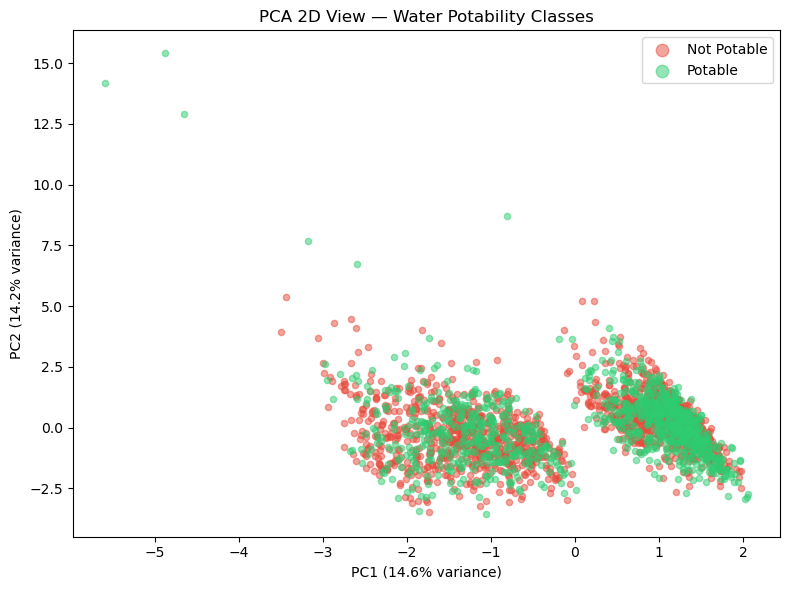

In [22]:
pca_2d = PCA(n_components=2, random_state=42)
X_2d   = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
colors = {0: '#e74c3c', 1: '#2ecc71'}
labels = {0: 'Not Potable', 1: 'Potable'}

for label in [0, 1]:
    mask = y_train == label
    plt.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=colors[label], label=labels[label],
        alpha=0.5, s=20
    )

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA 2D View — Water Potability Classes')
plt.legend(markerscale=2)
plt.tight_layout()
plt.show()

# Part A Summary

In [23]:
print('=' * 55)
print('  PART A — DATA PREPROCESSING SUMMARY')
print('=' * 55)

print('\nDATA CLEANING')
print(f'  Original shape         : {df_raw.shape}')
print(f'  Missing values fixed   : ph, Sulfate, Trihalomethanes')
print(f'  Method                 : fillna(median)')
print(f'  Duplicates removed     : 0')
print(f'  Outliers treated       : IQR capping for all features')
print(f'  Shape after cleaning   : {df.shape}')

print('\nDATA TRANSFORMATION')
print(f'  Features engineered    : ph_deviation, is_safe_ph,')
print(f'                           hardness_solids_ratio')
print(f'  Scaling method         : StandardScaler (Trying MinMaxScaler and RobustScaler)')
print(f'  Train / Test split     : 80% / 20%')
print(f'  Train size             : {X_train.shape[0]} samples')
print(f'  Test size              : {X_test.shape[0]} samples')

print('\nDATA REDUCTION')
print(f'  Feature selection      : ANOVA F-Score (top 7)')
print(f'  PCA variance retained  : 98%')
print(f'  Original features      : {X_train_scaled.shape[1]}')
print(f'  After feature select   : {X_train_selected.shape[1]}')
print(f'  After PCA              : {X_train_pca.shape[1]} components')

print('\n' + '=' * 55)
print('Data is ready for Part B — Machine Learning!')
print('=' * 55)

  PART A — DATA PREPROCESSING SUMMARY

DATA CLEANING
  Original shape         : (3276, 10)
  Missing values fixed   : ph, Sulfate, Trihalomethanes
  Method                 : fillna(median)
  Duplicates removed     : 0
  Outliers treated       : IQR capping for all features
  Shape after cleaning   : (3276, 13)

DATA TRANSFORMATION
  Features engineered    : ph_deviation, is_safe_ph,
                           hardness_solids_ratio
  Scaling method         : StandardScaler (Trying MinMaxScaler and RobustScaler)
  Train / Test split     : 80% / 20%
  Train size             : 2620 samples
  Test size              : 656 samples

DATA REDUCTION
  Feature selection      : ANOVA F-Score (top 7)
  PCA variance retained  : 98%
  Original features      : 12
  After feature select   : 7
  After PCA              : 11 components

Data is ready for Part B — Machine Learning!


In [24]:
df.to_csv("water_potability_cleaned.csv", index=False)

# Part B: Machine Learning Models — Water Potability Classification

**Dataset:** `water_potability_cleaned.csv` (preprocessed by Part A)  
**Target:** `Potability` (0 = Not Potable, 1 = Potable)  
**Task:** Binary Classification  

**Models:**
- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- k-Nearest Neighbors (kNN)
- Gradient Boosting

### Load Dataset & Import Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [26]:
data_path = "water_potability_cleaned.csv"
df = pd.read_csv(data_path)

print(f"Shape          : {df.shape}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"\nTarget distribution:")
print(df['Potability'].value_counts())
df.head()

Shape          : (3276, 13)
Missing values : 0

Target distribution:
Potability
0    1998
1    1278
Name: count, dtype: int64


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,ph_deviation,is_safe_ph,hardness_solids_ratio
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0,0.080795,1,0.009854
1,3.889107,129.422921,18630.057858,6.635246,333.073546,592.885359,15.180013,56.329076,4.500656,0,3.110893,0,0.006947
2,8.099124,224.236259,19909.541732,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934,0,1.099124,1,0.011262
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0,1.316766,1,0.009736
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0,2.092223,0,0.010072


### Split Features (X) and Target (y)

- **X** = all columns except `Potability` (12 input features)  
- **y** = `Potability` column (0 = Not Potable, 1 = Potable)

In [27]:
X = df.drop(columns=["Potability"])
y = df["Potability"]

print(f"X shape : {X.shape}  → features")
print(f"y shape : {y.shape}  → target")
print(f"\nFeatures: {list(X.columns)}")

X shape : (3276, 12)  → features
y shape : (3276,)  → target

Features: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'ph_deviation', 'is_safe_ph', 'hardness_solids_ratio']


### Define Models & KFold

KFold with 5 splits is used instead of a fixed train/test split — this gives a more reliable performance estimate by testing on every part of the data.

`class_weight='balanced'` is set for Logistic Regression to handle the class imbalance (61% Not Potable vs 39% Potable).

In [28]:
models = {
    'Logistic Regression' : LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Decision Tree'        : DecisionTreeClassifier(random_state=42),
    'Random Forest'        : RandomForestClassifier(random_state=42),
    'SVM'                  : SVC(random_state=42),
    'kNN'                  : KNeighborsClassifier(),
    'Gradient Boosting'    : GradientBoostingClassifier(random_state=42),
}

# Models that need StandardScaler
scaled_models = {'Logistic Regression', 'SVM', 'kNN'}

# KFold — 5 folds, shuffle before splitting
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Models defined:")
for name in models:
    tag = "  ← needs scaling" if name in scaled_models else ""
    print(f"  • {name}{tag}")
print(f"\nKFold: 5 splits, shuffle=True")

Models defined:
  • Logistic Regression  ← needs scaling
  • Decision Tree
  • Random Forest
  • SVM  ← needs scaling
  • kNN  ← needs scaling
  • Gradient Boosting

KFold: 5 splits, shuffle=True


### Hyperparameter Tuning with GridSearchCV

GridSearchCV tests every combination of hyperparameters using 5-fold cross-validation and selects the best combination based on **F1-score**.

For models that need scaling (Logistic Regression, SVM, kNN), a **Pipeline** is used so the scaler is fitted only on the training fold — this prevents data leakage.

In [29]:
param_grids = {
    'Logistic Regression': {
        'model__C'      : [0.01, 0.1, 1, 10],
        'model__solver' : ['lbfgs', 'liblinear'],
    },
    'Decision Tree': {
        'max_depth'        : [3, 5, 10, None], # try 4 different depths,max_depth = How many levels of questions the tree can ask
        'min_samples_split': [2, 5, 10], # min_samples_split, 10 means don't split if less than 10 samples
        'criterion'        : ['gini', 'entropy'], # criterion, gini or entropy — both are formulas, gini is faster
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200], # How many trees to build (more = better but slower)
        'max_depth'   : [5, 10, None], # How deep each tree can go
        'max_features': ['sqrt', 'log2'], # How many features each tree considers at each split
    },
    'SVM': {
        'model__C'     : [0.1, 1, 10], # How strict the boundary is — small C = flexible, large C = strict
        'model__kernel': ['rbf', 'linear'], # Shape of the boundary — rbf is curved, linear is straight
        'model__gamma' : ['scale', 'auto'], # How far each data point's influence reaches
    },
    'kNN': {
        'model__n_neighbors': [3, 5, 7, 11], # How many nearest neighbours to look at
        'model__weights'    : ['uniform', 'distance'], # uniform = all neighbours equal, distance = closer neighbours matter more
        'model__metric'     : ['euclidean', 'manhattan'], # How to measure distance — euclidean (straight line) or manhattan (grid steps)
    },
    'Gradient Boosting': {
        'n_estimators' : [50, 100, 200], # How many trees to build one after another
        'learning_rate': [0.05, 0.1, 0.2], # How fast it learns — smaller is slower but more careful
        'max_depth'    : [3, 5], # How deep each tree can go
    },
}

best_params = {} # will store the winning settings for each model
best_models = {} # will store the trained model with winning settings

for name, model in models.items():

    # Use Pipeline for models that need scaling
    # This ensures the scaler only sees training data in each fold (no data leakage)
    if name in scaled_models:
        estimator = Pipeline([
            ('scaler', StandardScaler()),
            ('model',  model)
        ])
    else:
        estimator = model

    grid = GridSearchCV(estimator, param_grids[name], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X, y)

    best_params[name] = grid.best_params_ # save the winning settings
    best_models[name] = grid.best_estimator_ # save the model trained with those settings

    print(f"{name}")
    print(f"  Best params : {grid.best_params_}")
    print(f"  Best F1     : {grid.best_score_:.4f}")
    print()

print("Hyperparameter tuning complete!")

Logistic Regression
  Best params : {'model__C': 1, 'model__solver': 'lbfgs'}
  Best F1     : 0.4665

Decision Tree
  Best params : {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5}
  Best F1     : 0.4490

Random Forest
  Best params : {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 50}
  Best F1     : 0.3759

SVM
  Best params : {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
  Best F1     : 0.4334

kNN
  Best params : {'model__metric': 'euclidean', 'model__n_neighbors': 3, 'model__weights': 'distance'}
  Best F1     : 0.3943

Gradient Boosting
  Best params : {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
  Best F1     : 0.4076

Hyperparameter tuning complete!


## Evaluate Best Models Using KFold

Using the best models found by GridSearchCV, we now evaluate each model across all 5 folds and average the results.

For models using a Pipeline, the scaler is fitted fresh on each training fold — ensuring no leakage.

In [30]:
results = {}

for name, model in best_models.items():
    acc_list, prec_list, rec_list, f1_list = [], [], [], []

    for train_idx, test_idx in kf.split(X, y):

        X_train_fold = X.iloc[train_idx]
        X_test_fold  = X.iloc[test_idx]
        y_train_fold = y.iloc[train_idx]
        y_test_fold  = y.iloc[test_idx]

        # If it's a Pipeline, it handles scaling internally
        # If it's a plain model (DT, RF, GB), no scaling needed
        if name in scaled_models:
            # Re-create pipeline per fold to fit scaler only on train fold
            base_model = models[name]
            pipe = Pipeline([('scaler', StandardScaler()), ('model', base_model)])
            pipe.set_params(**{k: v for k, v in best_params[name].items()})
            pipe.fit(X_train_fold, y_train_fold)
            y_pred = pipe.predict(X_test_fold)
        else:
            model.fit(X_train_fold, y_train_fold)
            y_pred = model.predict(X_test_fold)

        acc_list.append (accuracy_score (y_test_fold, y_pred))
        prec_list.append(precision_score(y_test_fold, y_pred, zero_division=0))
        rec_list.append (recall_score   (y_test_fold, y_pred, zero_division=0))
        f1_list.append  (f1_score       (y_test_fold, y_pred, zero_division=0))

    results[name] = {
        'Accuracy'  : round(np.mean(acc_list),  4),
        'Precision' : round(np.mean(prec_list), 4),
        'Recall'    : round(np.mean(rec_list),  4),
        'F1-Score'  : round(np.mean(f1_list),   4),
    }

    print(f"{name:25s} → Accuracy: {np.mean(acc_list):.4f}  "
          f"Precision: {np.mean(prec_list):.4f}  "
          f"Recall: {np.mean(rec_list):.4f}  "
          f"F1: {np.mean(f1_list):.4f}")

Logistic Regression       → Accuracy: 0.5067  Precision: 0.4021  Recall: 0.5479  F1: 0.4635
Decision Tree             → Accuracy: 0.5693  Precision: 0.4469  Recall: 0.4462  F1: 0.4463
Random Forest             → Accuracy: 0.6560  Precision: 0.6132  Recall: 0.3268  F1: 0.4258
SVM                       → Accuracy: 0.6624  Precision: 0.6022  Recall: 0.4075  F1: 0.4846
kNN                       → Accuracy: 0.6151  Precision: 0.5075  Recall: 0.4170  F1: 0.4576
Gradient Boosting         → Accuracy: 0.6502  Precision: 0.5701  Recall: 0.4157  F1: 0.4807


## Model Comparison Table

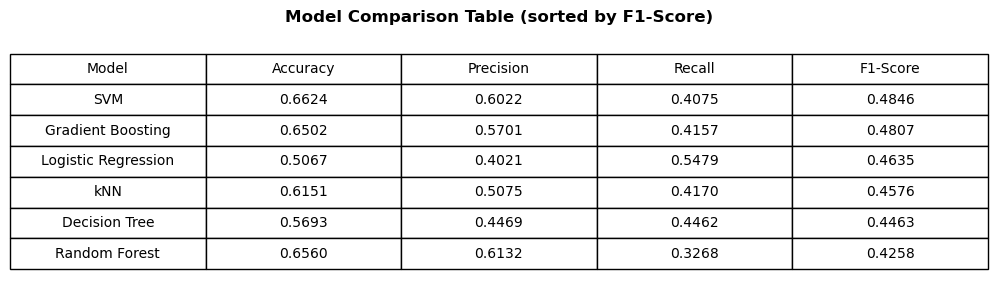

>>> Best model  : SVM  (F1 = 0.4846)
>>> Worst model : Random Forest  (F1 = 0.4258)


In [31]:
results_df = pd.DataFrame(results).T.sort_values('F1-Score', ascending=False)
model_names = list(results_df.index)

col_labels = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
table_data  = [[name] + [f"{results[name][m]:.4f}" for m in ['Accuracy','Precision','Recall','F1-Score']]
               for name in model_names]

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

table = ax.table(
    cellText  = table_data,
    colLabels = col_labels,
    loc       = 'center',
    cellLoc   = 'center',
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

plt.title('Model Comparison Table (sorted by F1-Score)', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('model_comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()

print(f">>> Best model  : {results_df.index[0]}  (F1 = {results_df['F1-Score'].iloc[0]})")
print(f">>> Worst model : {results_df.index[-1]}  (F1 = {results_df['F1-Score'].iloc[-1]})")

## Visualisation: Bar Chart

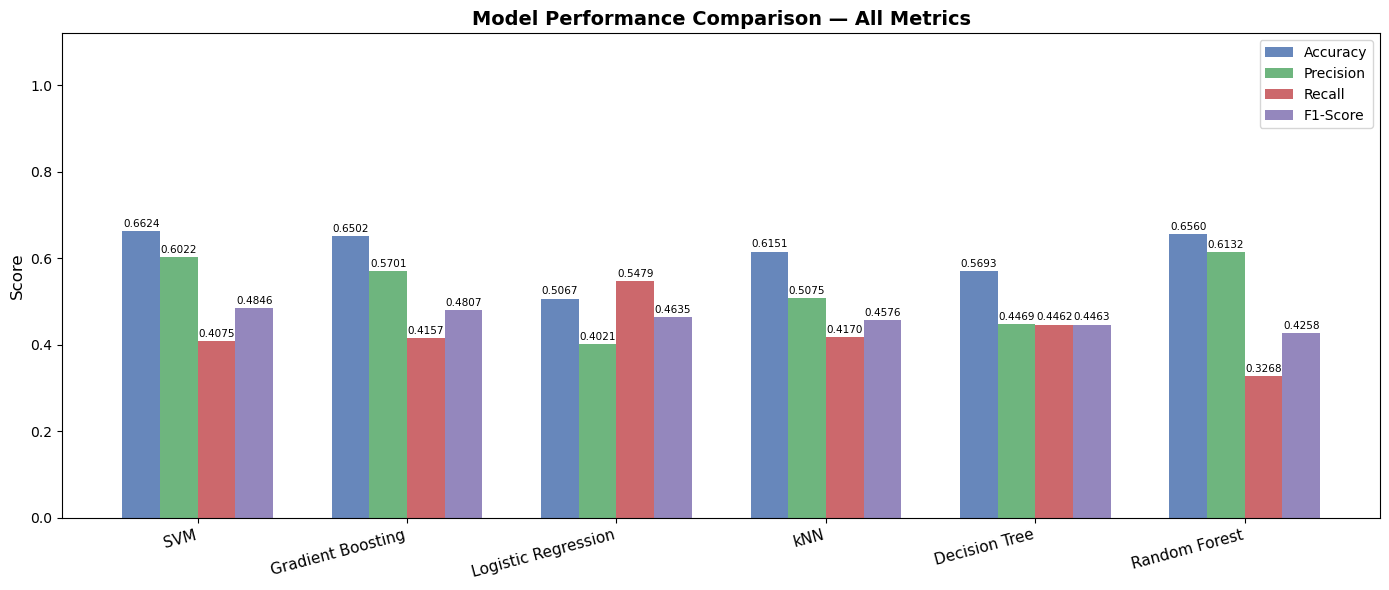

In [32]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors  = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(14, 6))
x     = np.arange(len(model_names))
width = 0.18

for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(x + i * width, vals, width, label=metric, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig('bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Performance Analysis

### Overall Comparison
Based on the table, SVM achieved the highest accuracy (0.6624), followed by Random Forest (0.6560) and Gradient Boosting (0.6502). 

However, accuracy alone is not the best metric for this dataset due to class imbalance. When considering F1-Score, which balances both precision and recall, SVM ranked best (0.4846), followed by Gradient Boosting (0.4807) and Logistic Regression (0.4635).

### Best Model
SVM is selected as the best overall model based on its highest accuracy (0.6624) and the highest F1-Score (0.4846). 

Although Random Forest achieved the highest precision (0.6132), SVM maintained a more balanced performance across all four metrics, making it the most consistent and reliable model overall.

### Worst Model
Random Forest had the lowest F1-Score (0.4258) and the lowest recall (0.3268), meaning it missed the most actual potable water samples and incorrectly classified them as not potable.Despite having the second highest accuracy (0.6560), its poor recall makes it unreliable for this task. 

Logistic Regression had the lowest accuracy (0.5067), performing only slightly better than random guessing.

### Key Observation
All models show a noticeable gap between accuracy and recall. This is likely caused by the class imbalance in the dataset (61% non-potable vs 39% potable), where models tend to favour predicting the majority class (not potable) more often.

In water safety applications, a low recall is particularly dangerous since it means the model fails to detect unsafe water, posing a health risk to consumers. Therefore, a model with balanced precision and recall is preferred over one with just high accuracy.

### Conclusion
SVM and Gradient Boosting are the most balanced models for this dataset, achieving the two highest F1-Scores of 0.4846 and 0.4807 respectively.